In [1]:
import copy
import math
import random

import matplotlib.pyplot as plt
import medmnist
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from medmnist import INFO
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms

from aijack.attack.inversion import GradientInversionAttackServerManager
from aijack.collaborative.fedavg import FedAVGAPI, FedAVGClient, FedAVGServer

# --------------------------
# 1. Experimental Configuration
# --------------------------
DATA_FLAG = "bloodmnist"
INPUT_SHAPE = (3, 28, 28)
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NUM_CLIENTS = 5
TARGET_BENIGN_CLIENT_ID = 0
COMMUNICATION_ROUNDS = 3

# Comparative dimensions
BATCH_SIZE_OPTIONS = [1, 4, 8]
LOCAL_EPOCH_OPTIONS = [1, 3, 5]

# Non-IID setup: each client sees only a small subset of labels
CLASSES_PER_CLIENT = 2
MIN_SAMPLES_PER_CLIENT = 96

CLIENT_LR = 0.01
SERVER_LR = 0.1

# Inversion hyperparameters
ATTACK_TRIALS = 3
ATTACK_STAGES = [
    {"name": "coarse", "num_iter": 450, "lr": 0.07, "tv": 2e-3, "l2": 2e-6, "early_stop": 160},
    {"name": "refine", "num_iter": 650, "lr": 0.035, "tv": 5e-4, "l2": 8e-7, "early_stop": 220},
]


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class MedMNISTSafe(Dataset):
    def __init__(self, data_flag: str, split: str, transform):
        info = INFO[data_flag]
        data_class = getattr(medmnist, info["python_class"])
        self.dataset = data_class(split=split, download=True, transform=transform)

        labels = getattr(self.dataset, "labels", None)
        if labels is None:
            collected = []
            for i in range(len(self.dataset)):
                _, y = self.dataset[i]
                collected.append(int(torch.as_tensor(y).squeeze().item()))
            self.targets = torch.as_tensor(collected, dtype=torch.long)
        else:
            self.targets = torch.as_tensor(labels).long().squeeze()

    def __getitem__(self, idx):
        img, target = self.dataset[idx]
        target = torch.as_tensor(target).long().squeeze()
        return img, target

    def __len__(self):
        return len(self.dataset)


class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((7, 7)),
        )
        self.fc = nn.Linear(32 * 7 * 7, num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


def create_noniid_client_indices(
    targets: torch.Tensor,
    num_clients: int,
    classes_per_client: int,
    min_samples_per_client: int,
    seed: int,
 ):
    rng = np.random.default_rng(seed)
    targets_np = targets.detach().cpu().numpy().astype(int)
    num_classes = int(targets_np.max()) + 1

    class_to_indices = {
        c: np.where(targets_np == c)[0].tolist() for c in range(num_classes)
    }
    for c in class_to_indices:
        rng.shuffle(class_to_indices[c])

    client_indices = []
    client_class_map = {}

    for client_id in range(num_clients):
        chosen_classes = sorted(
            rng.choice(num_classes, size=classes_per_client, replace=False).tolist()
        )
        client_class_map[client_id] = chosen_classes

        per_class_target = max(1, min_samples_per_client // classes_per_client)
        selected = []
        for cls in chosen_classes:
            take_n = min(per_class_target, len(class_to_indices[cls]))
            selected.extend(class_to_indices[cls][:take_n])
            class_to_indices[cls] = class_to_indices[cls][take_n:]

        if len(selected) < min_samples_per_client:
            for cls in chosen_classes:
                needed = min_samples_per_client - len(selected)
                if needed <= 0:
                    break
                take_n = min(needed, len(class_to_indices[cls]))
                selected.extend(class_to_indices[cls][:take_n])
                class_to_indices[cls] = class_to_indices[cls][take_n:]

        if len(selected) == 0:
            raise RuntimeError(
                f"Client {client_id} received 0 samples. Increase dataset size or lower constraints."
            )
        client_indices.append(selected)

    return client_indices, client_class_map


def attack_on_receive_multistage(server):
    round_results = []
    round_losses = []

    for trial in range(server.num_trial_per_communication):
        server.reset_seed(SEED + trial)
        stage_init_x = None
        trial_best_loss = float("inf")
        trial_best_x, trial_best_y = None, None

        for stage in ATTACK_STAGES:
            server.attacker.num_iteration = stage["num_iter"]
            server.attacker.tv_reg_coef = stage["tv"]
            server.attacker.l2_reg_coef = stage["l2"]
            server.attacker.early_stopping = stage["early_stop"]
            server.attacker.kwargs["lr"] = stage["lr"]

            try:
                recon_x, recon_y = server.attack(batch_size=1, init_x=stage_init_x)
            except OverflowError:
                continue

            stage_loss = (
                float(min(server.attacker.log_loss))
                if len(server.attacker.log_loss)
                else float("inf")
            )
            if not torch.isnan(recon_x).any() and stage_loss < trial_best_loss:
                trial_best_loss = stage_loss
                trial_best_x = recon_x.detach().clone()
                trial_best_y = recon_y.detach().clone()

            stage_init_x = recon_x.detach().clone().requires_grad_(True)

        if trial_best_x is not None:
            round_results.append((trial_best_x, trial_best_y))
            round_losses.append(trial_best_loss)

    server.attack_results.append(round_results)
    if not hasattr(server, "attack_loss_results"):
        server.attack_loss_results = []
    server.attack_loss_results.append(round_losses)


def denorm_image(x: torch.Tensor) -> torch.Tensor:
    return (x * 0.5 + 0.5).clamp(0, 1)


def compute_psnr(target: np.ndarray, recon: np.ndarray) -> float:
    mse = float(np.mean((target - recon) ** 2))
    if mse <= 1e-12:
        return float("inf")
    return float(20.0 * math.log10(1.0) - 10.0 * math.log10(mse))


def compute_ssim(target: np.ndarray, recon: np.ndarray) -> float:
    # Global SSIM over each channel, then average channels.
    c1 = (0.01 * 1.0) ** 2
    c2 = (0.03 * 1.0) ** 2

    vals = []
    for ch in range(target.shape[2]):
        x = target[..., ch]
        y = recon[..., ch]
        mu_x = float(x.mean())
        mu_y = float(y.mean())
        sigma_x = float(((x - mu_x) ** 2).mean())
        sigma_y = float(((y - mu_y) ** 2).mean())
        sigma_xy = float(((x - mu_x) * (y - mu_y)).mean())

        numerator = (2 * mu_x * mu_y + c1) * (2 * sigma_xy + c2)
        denominator = (mu_x**2 + mu_y**2 + c1) * (sigma_x + sigma_y + c2)
        vals.append(numerator / (denominator + 1e-12))

    return float(np.mean(vals))


def build_fedavg_with_inversion(batch_size: int, local_epoch: int, seed_offset: int = 0):
    set_seed(SEED + seed_offset)

    info = INFO[DATA_FLAG]
    num_classes = len(info["label"])

    transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ]
    )

    train_dataset = MedMNISTSafe(DATA_FLAG, split="train", transform=transform)
    client_indices, client_class_map = create_noniid_client_indices(
        targets=train_dataset.targets,
        num_clients=NUM_CLIENTS,
        classes_per_client=CLASSES_PER_CLIENT,
        min_samples_per_client=MIN_SAMPLES_PER_CLIENT,
        seed=SEED + seed_offset,
    )

    client_dataloaders = []
    for idxs in client_indices:
        client_dataloaders.append(
            DataLoader(
                Subset(train_dataset, idxs),
                batch_size=batch_size,
                shuffle=False,
                drop_last=False,
            )
        )

    base_model = SimpleCNN(num_classes).to(DEVICE)
    clients = [
        FedAVGClient(
            copy.deepcopy(base_model).to(DEVICE),
            user_id=i,
            lr=CLIENT_LR,
            device=DEVICE,
        )
        for i in range(NUM_CLIENTS)
    ]
    local_optimizers = [
        torch.optim.SGD(client.model.parameters(), lr=CLIENT_LR) for client in clients
    ]

    manager = GradientInversionAttackServerManager(
        x_shape=INPUT_SHAPE,
        attack_function_on_receive=attack_on_receive_multistage,
        target_client_id=TARGET_BENIGN_CLIENT_ID,
        num_trial_per_communication=ATTACK_TRIALS,
        optimize_label=True,
        distancename="cossim",
        optimizername="Adam",
        num_iteration=ATTACK_STAGES[0]["num_iter"],
        lr=ATTACK_STAGES[0]["lr"],
        tv_reg_coef=ATTACK_STAGES[0]["tv"],
        l2_reg_coef=ATTACK_STAGES[0]["l2"],
        clamp_range=(-1, 1),
        log_interval=100,
        early_stopping=ATTACK_STAGES[0]["early_stop"],
        device=DEVICE,
    )

    AttackFedAVGServer = manager.attach(FedAVGServer)
    server = AttackFedAVGServer(
        clients=clients,
        global_model=copy.deepcopy(base_model).to(DEVICE),
        lr=SERVER_LR,
        device=DEVICE,
    )

    criterion = nn.CrossEntropyLoss()
    api = FedAVGAPI(
        server,
        clients,
        criterion,
        local_optimizers,
        client_dataloaders,
        num_communication=COMMUNICATION_ROUNDS,
        local_epoch=local_epoch,
        use_gradients=True,
        device=DEVICE,
    )

    return api, server, train_dataset, client_indices, client_class_map


def run_single_configuration(batch_size: int, local_epoch: int, config_seed: int):
    api, server, train_dataset, client_indices, client_class_map = build_fedavg_with_inversion(
        batch_size=batch_size,
        local_epoch=local_epoch,
        seed_offset=config_seed,
    )

    api.run()

    target_dataset_idx = client_indices[TARGET_BENIGN_CLIENT_ID][0]
    target_img, target_label = train_dataset[target_dataset_idx]
    target_vis = denorm_image(target_img.detach().cpu()).permute(1, 2, 0).numpy()

    rows = []
    best_visual = None

    for round_idx, trial_results in enumerate(server.attack_results, start=1):
        if len(trial_results) == 0:
            continue

        losses = server.attack_loss_results[round_idx - 1] if hasattr(server, "attack_loss_results") else []
        if len(losses) == len(trial_results) and len(losses) > 0:
            best_idx = int(np.argmin(losses))
            attack_loss = float(losses[best_idx])
        else:
            best_idx = 0
            attack_loss = float("nan")

        recon_x, recon_y = trial_results[best_idx]
        recon_img = recon_x[0].detach().cpu()
        recon_vis = denorm_image(recon_img).permute(1, 2, 0).numpy()

        mse = float(np.mean((target_vis - recon_vis) ** 2))
        psnr = compute_psnr(target_vis, recon_vis)
        ssim = compute_ssim(target_vis, recon_vis)
        pred_label = int(recon_y[0].item()) if recon_y.ndim == 1 else int(recon_y[0].argmax().item())

        row = {
            "batch_size": batch_size,
            "local_epoch": local_epoch,
            "round": round_idx,
            "best_trial_idx": best_idx,
            "attack_loss": attack_loss,
            "mse": mse,
            "psnr": psnr,
            "ssim": ssim,
            "target_label": int(target_label),
            "pred_label": pred_label,
            "target_client_classes": str(client_class_map[TARGET_BENIGN_CLIENT_ID]),
        }
        rows.append(row)

        if best_visual is None or (np.isfinite(psnr) and psnr > best_visual["psnr"]):
            best_visual = {
                "round": round_idx,
                "recon_vis": recon_vis,
                "psnr": psnr,
                "ssim": ssim,
            }

    artifact = {
        "batch_size": batch_size,
        "local_epoch": local_epoch,
        "target_vis": target_vis,
        "target_label": int(target_label),
        "best_visual": best_visual,
        "target_client_classes": client_class_map[TARGET_BENIGN_CLIENT_ID],
    }
    return rows, artifact


def run_grid_experiments(batch_size_options, local_epoch_options):
    all_rows = []
    artifacts = []

    for bs in batch_size_options:
        for le in local_epoch_options:
            cfg_seed = bs * 100 + le
            rows, artifact = run_single_configuration(bs, le, cfg_seed)
            all_rows.extend(rows)
            artifacts.append(artifact)

    metrics_df = pd.DataFrame(all_rows)
    return metrics_df, artifacts


def summarize_metrics(metrics_df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        metrics_df.groupby(["batch_size", "local_epoch"], as_index=False)
        .agg(
            mean_psnr=("psnr", "mean"),
            mean_ssim=("ssim", "mean"),
            mean_mse=("mse", "mean"),
            mean_attack_loss=("attack_loss", "mean"),
        )
        .sort_values(["mean_psnr", "mean_ssim"], ascending=[False, False])
    )
    return summary


print("Setup complete.")
print("Next cell runs 9 configurations: batch_size in [1, 4, 8], local_epoch in [1, 3, 5].")

Setup complete.
Next cell runs 9 configurations: batch_size in [1, 4, 8], local_epoch in [1, 3, 5].


In [2]:
metrics_df, artifacts = run_grid_experiments(BATCH_SIZE_OPTIONS, LOCAL_EPOCH_OPTIONS)

print(f"Collected per-round metric rows: {len(metrics_df)}")
display(metrics_df.head(10))

summary_df = summarize_metrics(metrics_df)
print("\nConfiguration ranking (higher PSNR/SSIM is better for attacker):")
display(summary_df)

print("\nAverage metrics by batch size (gradient averaging effect):")
display(
    metrics_df.groupby("batch_size", as_index=False)
    .agg(mean_psnr=("psnr", "mean"), mean_ssim=("ssim", "mean"), mean_mse=("mse", "mean"))
    .sort_values("batch_size")
)

print("\nAverage metrics by local_epoch (multi-step local training impact):")
display(
    metrics_df.groupby("local_epoch", as_index=False)
    .agg(mean_psnr=("psnr", "mean"), mean_ssim=("ssim", "mean"), mean_mse=("mse", "mean"))
    .sort_values("local_epoch")
)

iter=100: 0.18551556766033173, (best_iter=100: 0.18551556766033173)
iter=200: 0.18080900609493256, (best_iter=188: 0.17813678085803986)
iter=300: 0.1779586374759674, (best_iter=254: 0.1765388548374176)
iter=400: 0.17714759707450867, (best_iter=377: 0.1747688502073288)
iter=100: 0.1777726411819458, (best_iter=98: 0.17692679166793823)
iter=200: 0.17354141175746918, (best_iter=199: 0.17332351207733154)
iter=300: 0.1761600822210312, (best_iter=211: 0.17268481850624084)
iter=400: 0.1761431246995926, (best_iter=211: 0.17268481850624084)
iter=432: loss did not improve in the last 220 rounds.
iter=100: 0.18465273082256317, (best_iter=85: 0.1830686330795288)
iter=200: 0.1813565492630005, (best_iter=143: 0.18076545000076294)
iter=300: 0.17972363531589508, (best_iter=289: 0.17777013778686523)
iter=400: 0.1778177171945572, (best_iter=337: 0.1768588423728943)
iter=100: 0.17918236553668976, (best_iter=100: 0.17918236553668976)
iter=200: 0.17830558121204376, (best_iter=181: 0.1773896962404251)
iter=3

,batch_size,local_epoch,round,best_trial_idx,attack_loss,mse,psnr,ssim,target_label,pred_label,target_client_classes
0,1,1,1,2,0.172135,0.123588,9.080247,0.093970,1,2,"[1, 2]"
1,1,1,2,2,0.183299,0.054322,12.650248,0.580042,1,2,"[1, 2]"
2,1,1,3,2,0.455047,0.135926,8.666976,-0.028701,1,7,"[1, 2]"
3,1,3,1,1,0.388167,0.156072,8.066757,-0.006723,3,7,"[3, 7]"
4,1,3,2,1,0.130573,0.043984,13.567055,0.513240,3,3,"[3, 7]"
5,1,3,3,0,0.010023,0.066986,11.740172,0.297916,3,6,"[3, 7]"
6,1,5,1,2,0.332553,0.136715,8.641840,-0.114351,0,4,"[0, 4]"
7,1,5,2,0,0.004156,0.028184,15.500036,0.667135,0,5,"[0, 4]"
8,1,5,3,1,0.436879,0.150319,8.229868,0.132857,0,0,"[0, 4]"
9,4,1,1,1,0.171864,0.089603,10.476792,0.272087,0,1,"[0, 1]"



Configuration ranking (higher PSNR/SSIM is better for attacker):


,batch_size,local_epoch,mean_psnr,mean_ssim,mean_mse,mean_attack_loss
3,4,1,12.847671,0.442528,0.060410,0.059003
8,8,5,11.631892,0.368765,0.075193,0.058526
7,8,3,11.555366,0.350179,0.072910,0.079452
6,8,1,11.200802,0.316583,0.085784,0.132566
1,1,3,11.124661,0.268144,0.089014,0.176254
2,1,5,10.790582,0.228547,0.105072,0.257863
4,4,3,10.566922,0.116902,0.090021,0.190583
5,4,5,10.228607,0.151227,0.096840,0.189708
0,1,1,10.132490,0.215104,0.104612,0.270160



Average metrics by batch size (gradient averaging effect):


,batch_size,mean_psnr,mean_ssim,mean_mse
0,1,10.682578,0.237265,0.099566
1,4,11.214400,0.236886,0.082423
2,8,11.462687,0.345176,0.077962



Average metrics by local_epoch (multi-step local training impact):


,local_epoch,mean_psnr,mean_ssim,mean_mse
0,1,11.393655,0.324738,0.083602
1,3,11.082316,0.245075,0.083981
2,5,10.883694,0.249513,0.092368


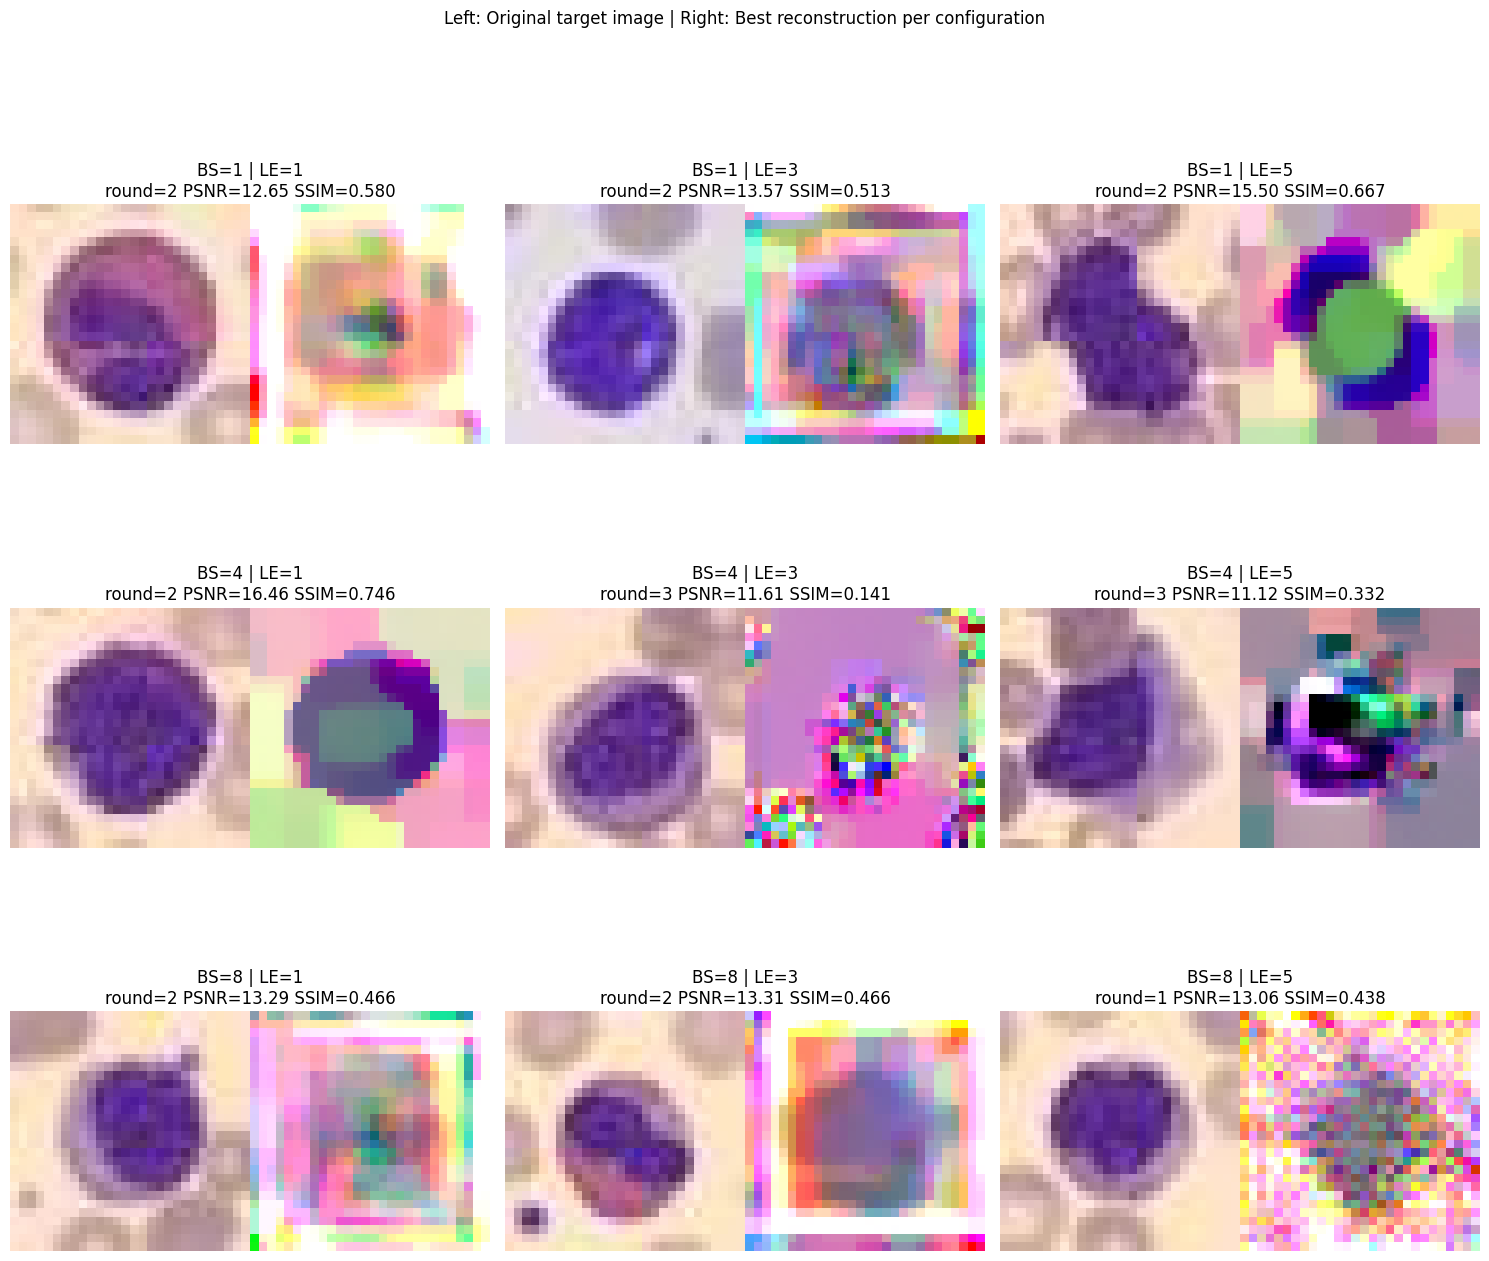

Interpretation support:
1) Batch size scaling: larger batches generally average multiple samples in one gradient update,
   which weakens single-image inversion targets and tends to reduce PSNR/SSIM.
 batch_size  mean_psnr  mean_ssim
          1  10.682578   0.237265
          4  11.214400   0.236886
          8  11.462687   0.345176

2) Local training impact: increasing local_epoch adds multiple local update steps before aggregation,
   which usually blurs per-sample gradient signal and degrades inversion quality.
 local_epoch  mean_psnr  mean_ssim
           1  11.393655   0.324738
           3  11.082316   0.245075
           5  10.883694   0.249513

3) Non-IID setting integrity check:
   target client class subset in each run (2-class skew) is recorded in metrics_df['target_client_classes'].
 batch_size  local_epoch target_client_classes
          1            1                [1, 2]
          1            3                [3, 7]
          1            5                [0, 4]
     

In [3]:
n_cfg = len(artifacts)
n_cols = 3
n_rows = int(np.ceil(n_cfg / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, artifact in enumerate(artifacts):
    ax = axes[i]
    title = f"BS={artifact['batch_size']} | LE={artifact['local_epoch']}"
    if artifact["best_visual"] is None:
        ax.text(0.5, 0.5, "No reconstruction", ha="center", va="center")
        ax.set_title(title)
        ax.axis("off")
        continue

    recon_vis = artifact["best_visual"]["recon_vis"]
    target_vis = artifact["target_vis"]

    vis = np.concatenate([target_vis, recon_vis], axis=1)
    ax.imshow(vis)
    ax.set_title(
        f"{title}\n"
        f"round={artifact['best_visual']['round']} "
        f"PSNR={artifact['best_visual']['psnr']:.2f} "
        f"SSIM={artifact['best_visual']['ssim']:.3f}"
    )
    ax.axis("off")

for j in range(n_cfg, len(axes)):
    axes[j].axis("off")

plt.suptitle("Left: Original target image | Right: Best reconstruction per configuration", y=1.02)
plt.tight_layout()
plt.show()

summary_by_bs = (
    metrics_df.groupby("batch_size", as_index=False)
    .agg(mean_psnr=("psnr", "mean"), mean_ssim=("ssim", "mean"))
    .sort_values("batch_size")
)
summary_by_le = (
    metrics_df.groupby("local_epoch", as_index=False)
    .agg(mean_psnr=("psnr", "mean"), mean_ssim=("ssim", "mean"))
    .sort_values("local_epoch")
)

print("Interpretation support:")
print("1) Batch size scaling: larger batches generally average multiple samples in one gradient update,")
print("   which weakens single-image inversion targets and tends to reduce PSNR/SSIM.")
print(summary_by_bs.to_string(index=False))

print("\n2) Local training impact: increasing local_epoch adds multiple local update steps before aggregation,")
print("   which usually blurs per-sample gradient signal and degrades inversion quality.")
print(summary_by_le.to_string(index=False))

print("\n3) Non-IID setting integrity check:")
print("   target client class subset in each run (2-class skew) is recorded in metrics_df['target_client_classes'].")
print(metrics_df[["batch_size", "local_epoch", "target_client_classes"]].drop_duplicates().to_string(index=False))

In [6]:
# Diagnostic cell: lightweight checks for potential framework vs. methodology issues
import importlib.metadata as ilm

print("=== AIJack quick diagnostics ===")
try:
    print("aijack version:", ilm.version("aijack"))
except Exception as e:
    print("Could not read aijack version:", e)

# Keep diagnostics faster than the full experiment.
orig_rounds = COMMUNICATION_ROUNDS
orig_trials = ATTACK_TRIALS
orig_stages = copy.deepcopy(ATTACK_STAGES)

COMMUNICATION_ROUNDS = 1
ATTACK_TRIALS = 1
ATTACK_STAGES = [
    {"name": "diag", "num_iter": 80, "lr": 0.05, "tv": 1e-3, "l2": 1e-6, "early_stop": 40},
]

# 1) Fixed-seed consistency check across batch sizes.
print("\n[Check 1] Fixed-seed consistency (target sample and class subset)")
diag_seed = 999
consistency_rows = []
for bs in [1, 4, 8]:
    rows, artifact = run_single_configuration(batch_size=bs, local_epoch=1, config_seed=diag_seed)
    consistency_rows.append({
        "batch_size": bs,
        "target_label": artifact["target_label"],
        "target_client_classes": str(artifact["target_client_classes"]),
        "n_round_rows": len(rows),
        "mean_psnr": float(np.mean([r["psnr"] for r in rows])) if len(rows) else float("nan"),
        "mean_ssim": float(np.mean([r["ssim"] for r in rows])) if len(rows) else float("nan"),
    })
consistency_df = pd.DataFrame(consistency_rows)
display(consistency_df)

same_target_label = consistency_df["target_label"].nunique() == 1
same_classes = consistency_df["target_client_classes"].nunique() == 1
print("Fixed target label across batch sizes:", same_target_label)
print("Fixed target client classes across batch sizes:", same_classes)

# 2) log_loss reset behavior across repeated server.attack calls in one round.
print("\n[Check 2] attacker.log_loss behavior across repeated attack() calls")
diag_log = []

def _safe_log_len(attacker):
    return len(getattr(attacker, "log_loss", []))

def attack_on_receive_diag(server):
    round_results = []
    round_losses = []

    for trial in range(server.num_trial_per_communication):
        server.reset_seed(SEED + trial)
        stage_init_x = None
        trial_best_loss = float("inf")
        trial_best_x, trial_best_y = None, None

        for stage in ATTACK_STAGES:
            server.attacker.num_iteration = stage["num_iter"]
            server.attacker.tv_reg_coef = stage["tv"]
            server.attacker.l2_reg_coef = stage["l2"]
            server.attacker.early_stopping = stage["early_stop"]
            server.attacker.kwargs["lr"] = stage["lr"]

            len_before = _safe_log_len(server.attacker)
            try:
                recon_x, recon_y = server.attack(batch_size=1, init_x=stage_init_x)
            except OverflowError:
                diag_log.append({"trial": trial, "len_before": len_before, "len_after": _safe_log_len(server.attacker), "overflow": True})
                continue
            len_after = _safe_log_len(server.attacker)
            diag_log.append({"trial": trial, "len_before": len_before, "len_after": len_after, "overflow": False})

            stage_loss = (
                float(min(server.attacker.log_loss))
                if hasattr(server.attacker, "log_loss") and len(server.attacker.log_loss)
                else float("inf")
            )
            if not torch.isnan(recon_x).any() and stage_loss < trial_best_loss:
                trial_best_loss = stage_loss
                trial_best_x = recon_x.detach().clone()
                trial_best_y = recon_y.detach().clone()

            stage_init_x = recon_x.detach().clone().requires_grad_(True)

        if trial_best_x is not None:
            round_results.append((trial_best_x, trial_best_y))
            round_losses.append(trial_best_loss)

    server.attack_results.append(round_results)
    if not hasattr(server, "attack_loss_results"):
        server.attack_loss_results = []
    server.attack_loss_results.append(round_losses)

manager_diag = GradientInversionAttackServerManager(
    x_shape=INPUT_SHAPE,
    attack_function_on_receive=attack_on_receive_diag,
    target_client_id=TARGET_BENIGN_CLIENT_ID,
    num_trial_per_communication=ATTACK_TRIALS,
    optimize_label=True,
    distancename="cossim",
    optimizername="Adam",
    num_iteration=ATTACK_STAGES[0]["num_iter"],
    lr=ATTACK_STAGES[0]["lr"],
    tv_reg_coef=ATTACK_STAGES[0]["tv"],
    l2_reg_coef=ATTACK_STAGES[0]["l2"],
    clamp_range=(-1, 1),
    log_interval=50,
    early_stopping=ATTACK_STAGES[0]["early_stop"],
    device=DEVICE,
)

# Reuse dataset/client split from a fixed seed, but rebuild server/api with the diagnostic callback.
set_seed(SEED + diag_seed)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])
train_dataset = MedMNISTSafe(DATA_FLAG, split="train", transform=transform)
client_indices, _ = create_noniid_client_indices(
    targets=train_dataset.targets,
    num_clients=NUM_CLIENTS,
    classes_per_client=CLASSES_PER_CLIENT,
    min_samples_per_client=MIN_SAMPLES_PER_CLIENT,
    seed=SEED + diag_seed,
)
client_dataloaders = [
    DataLoader(Subset(train_dataset, idxs), batch_size=1, shuffle=False, drop_last=False)
    for idxs in client_indices
]

num_classes = len(INFO[DATA_FLAG]["label"])
base_model = SimpleCNN(num_classes).to(DEVICE)
clients = [
    FedAVGClient(copy.deepcopy(base_model).to(DEVICE), user_id=i, lr=CLIENT_LR, device=DEVICE)
    for i in range(NUM_CLIENTS)
]
local_optimizers = [torch.optim.SGD(client.model.parameters(), lr=CLIENT_LR) for client in clients]
AttackFedAVGServerDiag = manager_diag.attach(FedAVGServer)
server_diag = AttackFedAVGServerDiag(
    clients=clients,
    global_model=copy.deepcopy(base_model).to(DEVICE),
    lr=SERVER_LR,
    device=DEVICE,
)
api_diag = FedAVGAPI(
    server_diag,
    clients,
    nn.CrossEntropyLoss(),
    local_optimizers,
    client_dataloaders,
    num_communication=COMMUNICATION_ROUNDS,
    local_epoch=1,
    use_gradients=True,
    device=DEVICE,
)
api_diag.run()

diag_log_df = pd.DataFrame(diag_log)
display(diag_log_df)
if len(diag_log_df):
    print("Any non-zero len_before values:", bool((diag_log_df["len_before"] > 0).any()))
    print("Interpretation: non-zero len_before means log_loss is cumulative across calls unless user resets it.")

# restore original global settings
COMMUNICATION_ROUNDS = orig_rounds
ATTACK_TRIALS = orig_trials
ATTACK_STAGES = orig_stages
print("\nDiagnostics complete. Original experiment settings restored.")

=== AIJack quick diagnostics ===
aijack version: 0.0.1b2

[Check 1] Fixed-seed consistency (target sample and class subset)


,batch_size,target_label,target_client_classes,n_round_rows,mean_psnr,mean_ssim
0,1,1,"[1, 2]",1,11.553265,0.311103
1,4,1,"[1, 2]",1,11.537930,0.303969
2,8,1,"[1, 2]",1,11.749419,0.318715


Fixed target label across batch sizes: True
Fixed target client classes across batch sizes: True

[Check 2] attacker.log_loss behavior across repeated attack() calls
iter=50: 0.16774049401283264, (best_iter=50: 0.16774049401283264)


,trial,len_before,len_after,overflow
0,0,0,80,False


Any non-zero len_before values: False
Interpretation: non-zero len_before means log_loss is cumulative across calls unless user resets it.

Diagnostics complete. Original experiment settings restored.
